In [1]:
# confusion metrices

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [149]:
data = pd.read_csv("loan_approval_nepal_clean_v2.csv")

In [150]:
data.head()

,name,age,monthly_income_npr,credit_score,existing_loans,loan_status
0,Purnima Bhandari,28,31049,357,1,Not Approved
1,Laxmi Yadav,55,17082,307,1,Not Approved
2,Bikram Bogati,53,50713,407,1,Not Approved
3,Devi Ghimire,38,25463,478,2,Not Approved
4,Ram Bhandari,30,72059,516,1,Hold


In [151]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   name                70 non-null     str  
 1   age                 70 non-null     int64
 2   monthly_income_npr  70 non-null     int64
 3   credit_score        70 non-null     int64
 4   existing_loans      70 non-null     int64
 5   loan_status         70 non-null     str  
dtypes: int64(4), str(2)
memory usage: 3.4 KB


In [152]:
X = data[['monthly_income_npr', 'credit_score']]
y = data['loan_status']

In [153]:
X.head()

,monthly_income_npr,credit_score
0,31049,357
1,17082,307
2,50713,407
3,25463,478
4,72059,516


In [154]:
y

0     Not Approved
1     Not Approved
2     Not Approved
3     Not Approved
4             Hold
          ...     
65    Not Approved
66        Approved
67        Approved
68    Not Approved
69        Approved
Name: loan_status, Length: 70, dtype: str

In [155]:
data['loan_status'].value_counts()

loan_status
Not Approved    35
Approved        22
Hold            13
Name: count, dtype: int64

In [156]:
# decision tree

In [157]:
from sklearn.tree import DecisionTreeClassifier

In [158]:
model = DecisionTreeClassifier()

In [159]:
X_train, X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [160]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [161]:
# accuracy score

In [162]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score

In [163]:
X_test

,monthly_income_npr,credit_score
22,60821,557
0,31049,357
49,137875,826
4,72059,516
54,80847,546
18,21973,460
10,18665,358
33,46546,354
45,86256,529
12,80071,526


In [164]:
y_true = y_test

In [165]:
y_pred = model.predict(X_test)

In [166]:
y_true

22            Hold
0     Not Approved
49        Approved
4             Hold
54            Hold
18    Not Approved
10    Not Approved
33    Not Approved
45            Hold
12            Hold
31    Not Approved
9     Not Approved
67        Approved
5     Not Approved
Name: loan_status, dtype: str

In [167]:
y_pred

array(['Hold', 'Not Approved', 'Approved', 'Hold', 'Approved',
       'Not Approved', 'Not Approved', 'Not Approved', 'Approved', 'Hold',
       'Not Approved', 'Not Approved', 'Approved', 'Not Approved'],
      dtype=object)

In [168]:
accuracy_score(y_true, y_pred)

0.8571428571428571

In [169]:
cm = confusion_matrix(y_true, y_pred, labels=model.classes_)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

In [170]:
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

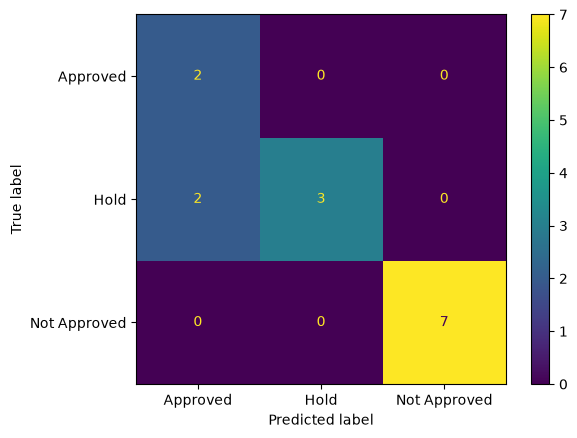

In [171]:
cm_display.plot()